# MODELO FCN-8s - ENTRENAMIENTO COMPLETO
Usa datos preprocesados desde data_minimal.pkl

## Imports y configuración

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Configuración
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

plt.rcParams['figure.figsize'] = (15, 5)

🖥️  Device: cuda
   GPU: Tesla T4
   Memoria: 15.83 GB


## Creación de modelo

In [9]:
from FCN8s import FCN8s

# Crear modelo
model = FCN8s(num_classes=2, pretrained=True).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("MODELO: FCN-8s")
print(f"Parámetros totales: {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Backbone: VGG16 preentrenado en ImageNet")

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 103MB/s]


MODELO: FCN-8s
Parámetros totales: 134,271,430 (134.3M)
Parámetros entrenables: 134,271,430
Backbone: VGG16 preentrenado en ImageNet


## Uso de datos preprocesados

In [ ]:
# Cargar el archivo
with open('/content/data_minimal.pkl', 'rb') as f:
    data = pickle.load(f)

# Importar clase externa
from dataset_form import train_transform, val_transform, SimpleDataset

In [11]:
# Extraer datos
train_tiles = data['train']
val_tiles = data['val']
test_tiles = data['test']
annotations_dict = data['annotations']

# Crear datasets y loaders
train_dataset = SimpleDataset(train_tiles, '/content/hubmap_data/train', annotations_dict, train_transform)
val_dataset = SimpleDataset(val_tiles, '/content/hubmap_data/train', annotations_dict, val_transform)
test_dataset = SimpleDataset(test_tiles, '/content/hubmap_data/train', annotations_dict, val_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f"Datos cargados:")
print(f"   Train: {len(train_dataset)} tiles")
print(f"   Val: {len(val_dataset)} tiles")
print(f"   Test: {len(test_dataset)} tiles\n")

Datos cargados:
   Train: 4923 tiles
   Val: 1055 tiles
   Test: 1055 tiles



## Para uso de métricas

In [12]:
def calculate_metrics(predictions, targets):
    """
    Calcula: Precision, Recall, F1, Dice Score, IoU
    predictions: [B, 2, H, W] (logits)
    targets: [B, H, W] (0, 1, 255)
    """
    # Convertir a predicciones binarias
    preds = torch.argmax(predictions, dim=1)  # [B, H, W]

    # Filtrar valores válidos (ignorar 255)
    valid_mask = (targets != 255)
    preds_valid = preds[valid_mask].cpu().numpy()
    targets_valid = targets[valid_mask].cpu().numpy()

    # Evitar división por cero
    if len(preds_valid) == 0 or len(np.unique(targets_valid)) < 2:
        return {
            'precision': 0.0,
            'recall': 0.0,
            'f1': 0.0,
            'dice': 0.0,
            'iou': 0.0
        }

    # Calcular métricas con sklearn
    precision = precision_score(targets_valid, preds_valid, zero_division=0)
    recall = recall_score(targets_valid, preds_valid, zero_division=0)
    f1 = f1_score(targets_valid, preds_valid, zero_division=0)

    # Dice Score
    intersection = np.sum(preds_valid * targets_valid)
    union = np.sum(preds_valid) + np.sum(targets_valid)
    dice = (2. * intersection + 1e-7) / (union + 1e-7)

    # IoU
    intersection_iou = np.sum(preds_valid * targets_valid)
    union_iou = np.sum(preds_valid) + np.sum(targets_valid) - intersection_iou
    iou = (intersection_iou + 1e-7) / (union_iou + 1e-7)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'dice': dice,
        'iou': iou
    }

## Configuración de entrenamiento

In [14]:
# Hiperparámetros
EPOCHS = 30
LEARNING_RATE = 1e-4
PATIENCE = 5

# Loss function (ignora glomérulos con 255)
criterion = nn.CrossEntropyLoss(ignore_index=255)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

In [15]:
# Historial de métricas
history = {
    'train_loss': [],
    'val_loss': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'val_dice': [],
    'val_iou': [],
    'epoch_times': []
}

best_dice = 0.0
patience_counter = 0

print("CONFIGURACIÓN DE ENTRENAMIENTO")
print(f"Épocas: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Optimizer: Adam")
print(f"Loss: CrossEntropyLoss (ignore_index=255)")
print(f"Scheduler: ReduceLROnPlateau (patience=3)")
print(f"Early stopping: patience={PATIENCE}")

CONFIGURACIÓN DE ENTRENAMIENTO
Épocas: 30
Learning rate: 0.0001
Optimizer: Adam
Loss: CrossEntropyLoss (ignore_index=255)
Scheduler: ReduceLROnPlateau (patience=3)
Early stopping: patience=5


## Bucle de ENTRENAMIENTO

In [ ]:
print("INICIANDO ENTRENAMIENTO - FCN-8s")
for epoch in range(EPOCHS):
    epoch_start = time.time()

    # TRAINING
    model.train()
    train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False)
    for images, masks, tile_ids in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0.0
    val_metrics = {
        'precision': [],
        'recall': [],
        'f1': [],
        'dice': [],
        'iou': []
    }

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]', leave=False)
        for images, masks, tile_ids in val_bar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            # Calcular métricas
            metrics = calculate_metrics(outputs, masks)
            for key in val_metrics:
                val_metrics[key].append(metrics[key])

            val_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{metrics["dice"]:.4f}'
            })

    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    # Promediar métricas
    for key in val_metrics:
        avg_metric = np.mean(val_metrics[key])
        history[f'val_{key}'].append(avg_metric)

    avg_dice = np.mean(val_metrics['dice'])

    # Learning rate scheduling
    scheduler.step(avg_dice)

    # Tiempo de época
    epoch_time = time.time() - epoch_start
    history['epoch_times'].append(epoch_time)

    # Print epoch summary
    print(f"Epoch {epoch+1}/{EPOCHS} - Time: {epoch_time:.1f}s")
    print(f"Train Loss:     {avg_train_loss:.4f}")
    print(f"Val Loss:       {avg_val_loss:.4f}")
    print(f"Val Precision:  {np.mean(val_metrics['precision']):.4f}")
    print(f"Val Recall:     {np.mean(val_metrics['recall']):.4f}")
    print(f"Val F1-Score:   {np.mean(val_metrics['f1']):.4f}")
    print(f"Val Dice Score: {avg_dice:.4f}")
    print(f"Val IoU:        {np.mean(val_metrics['iou']):.4f}\n\n")

    # Guardar mejor modelo
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'dice_score': best_dice,
            'history': history
        }, 'best_fcn8s.pth')
        print(f"Mejor modelo guardado (Dice: {best_dice:.4f})\n")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"Early stopping activado en época {epoch+1}")
        break

print("ENTRENAMIENTO COMPLETADO")
print(f"Mejor Dice Score: {best_dice:.4f}")
print(f"Tiempo total: {sum(history['epoch_times'])/60:.1f} minutos")
print(f"Modelo guardado: best_fcn8s.pth")

#### **LOGS de ENTRENAMIENTO - FCN-8s**
Epoch 1/30 - Time: 871.3s
Train Loss:     0.1744
Val Loss:       0.0401
Val Precision:  0.2586
Val Recall:     0.0864
Val F1-Score:   0.1172
Val Dice Score: 0.1172
Val IoU:        0.0657


Mejor modelo guardado (Dice: 0.1172)

Epoch 2/30 - Time: 870.1s
Train Loss:     0.0413
Val Loss:       0.0345
Val Precision:  0.4622
Val Recall:     0.2381
Val F1-Score:   0.2884
Val Dice Score: 0.2884
Val IoU:        0.1838


Mejor modelo guardado (Dice: 0.2884)

Epoch 3/30 - Time: 873.1s
Train Loss:     0.0345
Val Loss:       0.0277
Val Precision:  0.5775
Val Recall:     0.2164
Val F1-Score:   0.2938
Val Dice Score: 0.2938
Val IoU:        0.1898


Mejor modelo guardado (Dice: 0.2938)

Epoch 4/30 - Time: 871.3s
Train Loss:     0.0306
Val Loss:       0.0266
Val Precision:  0.5005
Val Recall:     0.3463
Val F1-Score:   0.3843
Val Dice Score: 0.3843
Val IoU:        0.2605


Mejor modelo guardado (Dice: 0.3843)

Epoch 5/30 - Time: 874.3s
Train Loss:     0.0288
Val Loss:       0.0235
Val Precision:  0.6202
Val Recall:     0.2674
Val F1-Score:   0.3526
Val Dice Score: 0.3526
Val IoU:        0.2376


Epoch 6/30 - Time: 871.5s
Train Loss:     0.0272
Val Loss:       0.0255
Val Precision:  0.6474
Val Recall:     0.2417
Val F1-Score:   0.3340
Val Dice Score: 0.3340
Val IoU:        0.2212


Epoch 7/30 - Time: 871.2s
Train Loss:     0.0275
Val Loss:       0.0212
Val Precision:  0.5948
Val Recall:     0.3642
Val F1-Score:   0.4291
Val Dice Score: 0.4291
Val IoU:        0.3029


Mejor modelo guardado (Dice: 0.4291)

Epoch 8/30 - Time: 869.8s
Train Loss:     0.0253
Val Loss:       0.0204
Val Precision:  0.5528
Val Recall:     0.4471
Val F1-Score:   0.4728
Val Dice Score: 0.4728
Val IoU:        0.3426


Mejor modelo guardado (Dice: 0.4728)

Epoch 9/30 - Time: 871.5s
Train Loss:     0.0236
Val Loss:       0.0197
Val Precision:  0.5950
Val Recall:     0.4071
Val F1-Score:   0.4595
Val Dice Score: 0.4595
Val IoU:        0.3310


Epoch 10/30 - Time: 872.2s
Train Loss:     0.0236
Val Loss:       0.0213
Val Precision:  0.6264
Val Recall:     0.3331
Val F1-Score:   0.4149
Val Dice Score: 0.4149
Val IoU:        0.2900


Epoch 11/30 - Time: 871.2s
Train Loss:     0.0227
Val Loss:       0.0190
Val Precision:  0.5935
Val Recall:     0.4316
Val F1-Score:   0.4799
Val Dice Score: 0.4799
Val IoU:        0.3487


Mejor modelo guardado (Dice: 0.4799)

Epoch 12/30 - Time: 873.3s
Train Loss:     0.0226
Val Loss:       0.0185
Val Precision:  0.6144
Val Recall:     0.3991
Val F1-Score:   0.4651
Val Dice Score: 0.4651
Val IoU:        0.3361


Epoch 13/30 - Time: 872.7s
Train Loss:     0.0226
Val Loss:       0.0193
Val Precision:  0.5769
Val Recall:     0.4642
Val F1-Score:   0.4943
Val Dice Score: 0.4943
Val IoU:        0.3629


Mejor modelo guardado (Dice: 0.4943)

Epoch 14/30 - Time: 874.9s
Train Loss:     0.0214
Val Loss:       0.0181
Val Precision:  0.5940
Val Recall:     0.4595
Val F1-Score:   0.4947
Val Dice Score: 0.4947
Val IoU:        0.3635


Mejor modelo guardado (Dice: 0.4947)

**Por límites en el uso de Colab, se pausó el entrenamiento y se reanuda a continuación**

In [ ]:
# Cargar checkpoint
checkpoint = torch.load('best_fcn8s.pth', map_location=device, weights_only=False)

# Restaurar pesos del modelo y del optimizador
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Restaurar métricas y estado previo
best_dice = checkpoint['dice_score']
history = checkpoint['history']
start_epoch = checkpoint['epoch'] + 1  # continuar después de la última guardada

In [ ]:
print(f"Reanudando entrenamiento desde la época {start_epoch} con Dice: {best_dice:.4f}")

for epoch in range(start_epoch, EPOCHS):
    epoch_start = time.time()

    # TRAINING
    model.train()
    train_loss = 0.0

    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False)
    for images, masks, tile_ids in train_bar:
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0.0
    val_metrics = {
        'precision': [],
        'recall': [],
        'f1': [],
        'dice': [],
        'iou': []
    }

    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]', leave=False)
        for images, masks, tile_ids in val_bar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            # Calcular métricas
            metrics = calculate_metrics(outputs, masks)
            for key in val_metrics:
                val_metrics[key].append(metrics[key])

            val_bar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'dice': f'{metrics["dice"]:.4f}'
            })

    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)

    # Promediar métricas
    for key in val_metrics:
        avg_metric = np.mean(val_metrics[key])
        history[f'val_{key}'].append(avg_metric)

    avg_dice = np.mean(val_metrics['dice'])

    # Learning rate scheduling
    scheduler.step(avg_dice)

    # Tiempo de época
    epoch_time = time.time() - epoch_start
    history['epoch_times'].append(epoch_time)

    # Print epoch summary
    print(f"Epoch {epoch+1}/{EPOCHS} - Time: {epoch_time:.1f}s")
    print(f"Train Loss:     {avg_train_loss:.4f}")
    print(f"Val Loss:       {avg_val_loss:.4f}")
    print(f"Val Precision:  {np.mean(val_metrics['precision']):.4f}")
    print(f"Val Recall:     {np.mean(val_metrics['recall']):.4f}")
    print(f"Val F1-Score:   {np.mean(val_metrics['f1']):.4f}")
    print(f"Val Dice Score: {avg_dice:.4f}")
    print(f"Val IoU:        {np.mean(val_metrics['iou']):.4f}\n\n")

    # Guardar mejor modelo
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'dice_score': best_dice,
            'history': history
        }, 'best_fcn8s.pth') # Guardar en drive

        print(f"Mejor modelo guardado (Dice: {best_dice:.4f})\n")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"Early stopping activado en época {epoch+1}")
        break

print("ENTRENAMIENTO COMPLETADO")
print(f"Mejor Dice Score: {best_dice:.4f}")
print(f"Tiempo total: {sum(history['epoch_times'])/60:.1f} minutos")
print(f"Modelo guardado: best_fcn8s.pth")


Reanudando entrenamiento desde la época 14 con Dice: 0.4947
Mounted at /content/drive


Epoch 15/30 - Time: 827.4s
Train Loss:     0.0205
Val Loss:       0.0178
Val Precision:  0.5972
Val Recall:     0.4533
Val F1-Score:   0.4932
Val Dice Score: 0.4932
Val IoU:        0.3633




Epoch 16/30 - Time: 823.8s
Train Loss:     0.0205
Val Loss:       0.0175
Val Precision:  0.6299
Val Recall:     0.4058
Val F1-Score:   0.4762
Val Dice Score: 0.4762
Val IoU:        0.3461




Epoch 17/30 - Time: 825.2s
Train Loss:     0.0204
Val Loss:       0.0212
Val Precision:  0.5128
Val Recall:     0.5377
Val F1-Score:   0.5028
Val Dice Score: 0.5028
Val IoU:        0.3730


Mejor modelo guardado (Dice: 0.5028)



Epoch 18/30 - Time: 824.9s
Train Loss:     0.0205
Val Loss:       0.0172
Val Precision:  0.5878
Val Recall:     0.4753
Val F1-Score:   0.5063
Val Dice Score: 0.5063
Val IoU:        0.3764


Mejor modelo guardado (Dice: 0.5063)



Epoch 19/30 - Time: 823.8s
Train Loss:     0.0196
Val Loss:       0.0183
Val Precision:  0.6484
Val Recall:     0.3971
Val F1-Score:   0.4669
Val Dice Score: 0.4669
Val IoU:        0.3394




Epoch 20/30 - Time: 823.8s
Train Loss:     0.0213
Val Loss:       0.0205
Val Precision:  0.6148
Val Recall:     0.3868
Val F1-Score:   0.4550
Val Dice Score: 0.4550
Val IoU:        0.3256




Epoch 21/30 - Time: 824.3s
Train Loss:     0.0198
Val Loss:       0.0183
Val Precision:  0.6085
Val Recall:     0.4152
Val F1-Score:   0.4767
Val Dice Score: 0.4767
Val IoU:        0.3494




Epoch 22/30 - Time: 824.6s
Train Loss:     0.0181
Val Loss:       0.0182
Val Precision:  0.5788
Val Recall:     0.4738
Val F1-Score:   0.4989
Val Dice Score: 0.4989
Val IoU:        0.3688




Epoch 23/30 - Time: 824.3s
Train Loss:     0.0163
Val Loss:       0.0169
Val Precision:  0.6592
Val Recall:     0.4244
Val F1-Score:   0.4944
Val Dice Score: 0.4944
Val IoU:        0.3655


Early stopping activado en época 23
ENTRENAMIENTO COMPLETADO
Mejor Dice Score: 0.5063
Tiempo total: 327.2 minutos
Modelo guardado: best_fcn8s.pth


## Evaluación

In [ ]:
# Cargar mejor modelo
checkpoint = torch.load('best_fcn8s.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

FCN8s(
  (features_block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (features_block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (features_block3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inp

In [25]:
# Evaluar en test
test_metrics = {
    'precision': [],
    'recall': [],
    'f1': [],
    'dice': [],
    'iou': []
}

with torch.no_grad():
    test_bar = tqdm(test_loader, desc='Evaluando en Test')
    for images, masks, tile_ids in test_bar:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        metrics = calculate_metrics(outputs, masks)

        for key in test_metrics:
            test_metrics[key].append(metrics[key])

        test_bar.set_postfix({'dice': f'{metrics["dice"]:.4f}'})

Evaluando en Test: 100%|██████████| 132/132 [01:29<00:00,  1.48it/s, dice=0.8973]


In [26]:
print("RESULTADOS FINALES EN TEST SET")
for metric_name, values in test_metrics.items():
    mean = np.mean(values)
    std = np.std(values)
    print(f"{metric_name.capitalize():<12}: {mean:.4f} ± {std:.4f}")

RESULTADOS FINALES EN TEST SET
Precision   : 0.5609 ± 0.2946
Recall      : 0.4798 ± 0.2716
F1          : 0.4994 ± 0.2675
Dice        : 0.4994 ± 0.2675
Iou         : 0.3710 ± 0.2166


## Visualización

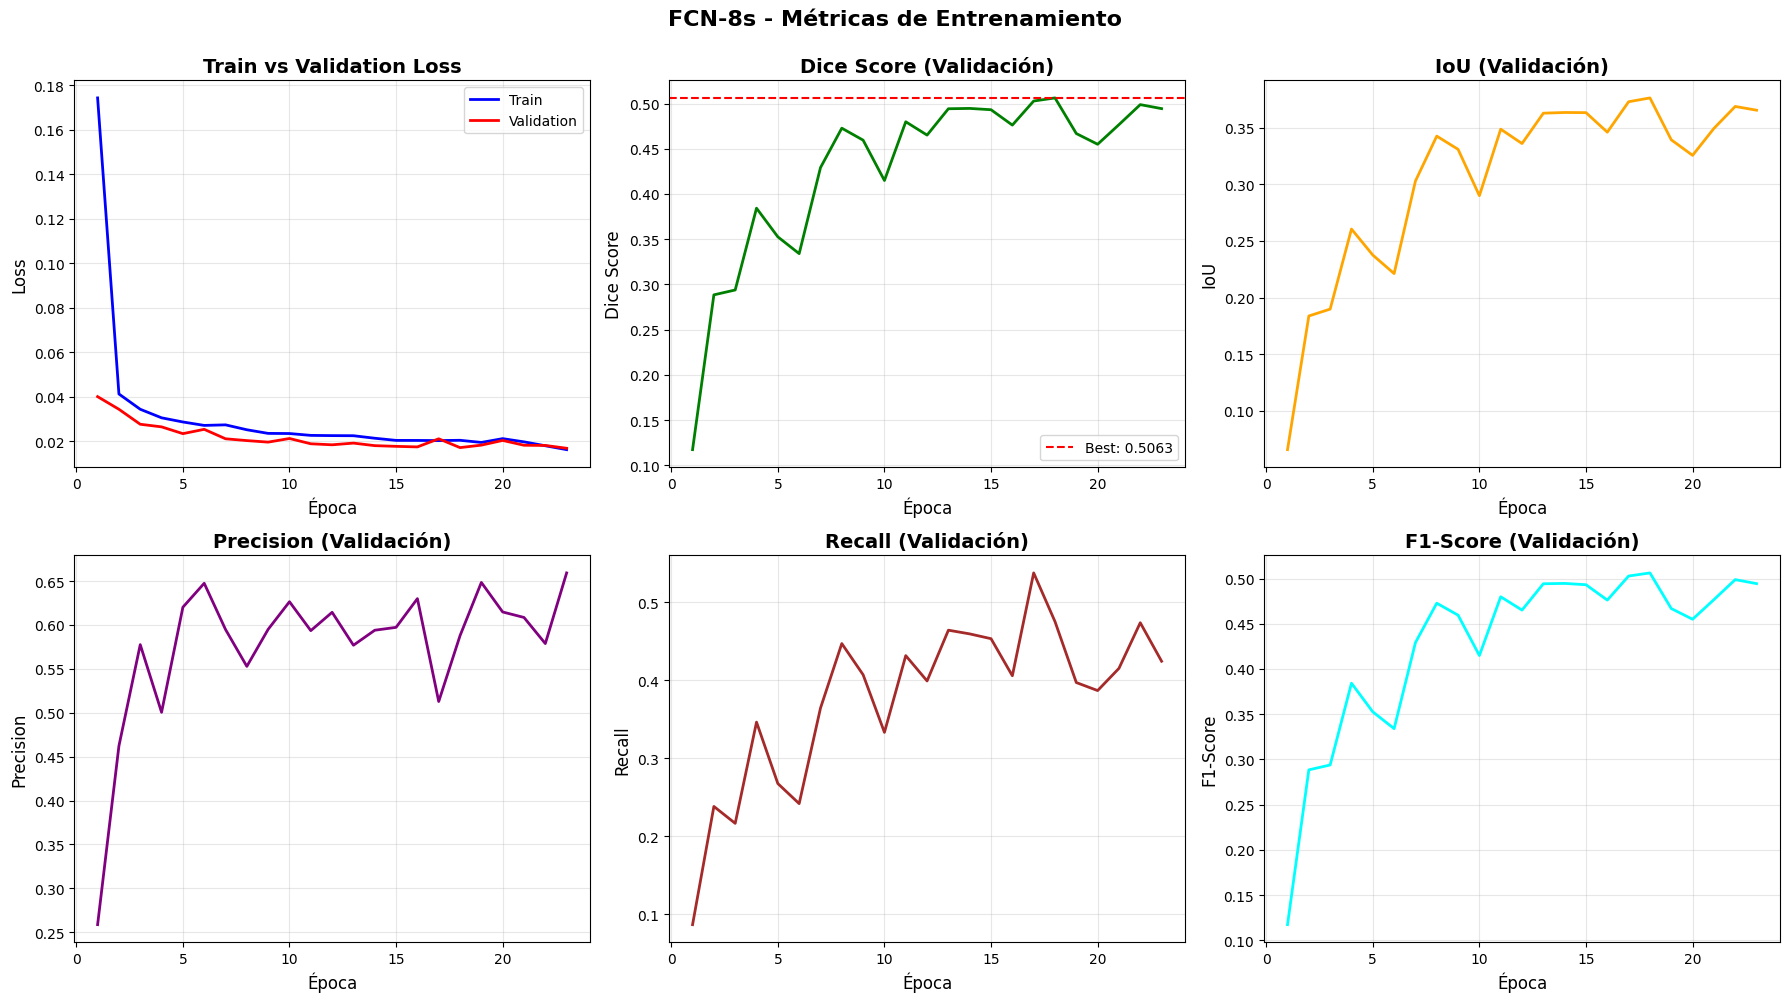

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[0, 0].set_xlabel('Época', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Train vs Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Dice Score
axes[0, 1].plot(epochs_range, history['val_dice'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Época', fontsize=12)
axes[0, 1].set_ylabel('Dice Score', fontsize=12)
axes[0, 1].set_title('Dice Score (Validación)', fontsize=14, fontweight='bold')
axes[0, 1].axhline(y=best_dice, color='r', linestyle='--', label=f'Best: {best_dice:.4f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# IoU
axes[0, 2].plot(epochs_range, history['val_iou'], 'orange', linewidth=2)
axes[0, 2].set_xlabel('Época', fontsize=12)
axes[0, 2].set_ylabel('IoU', fontsize=12)
axes[0, 2].set_title('IoU (Validación)', fontsize=14, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(epochs_range, history['val_precision'], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Época', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision (Validación)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(epochs_range, history['val_recall'], 'brown', linewidth=2)
axes[1, 1].set_xlabel('Época', fontsize=12)
axes[1, 1].set_ylabel('Recall', fontsize=12)
axes[1, 1].set_title('Recall (Validación)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

# F1-Score
axes[1, 2].plot(epochs_range, history['val_f1'], 'cyan', linewidth=2)
axes[1, 2].set_xlabel('Época', fontsize=12)
axes[1, 2].set_ylabel('F1-Score', fontsize=12)
axes[1, 2].set_title('F1-Score (Validación)', fontsize=14, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('FCN-8s - Métricas de Entrenamiento', fontsize=16, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig('fcn8s_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

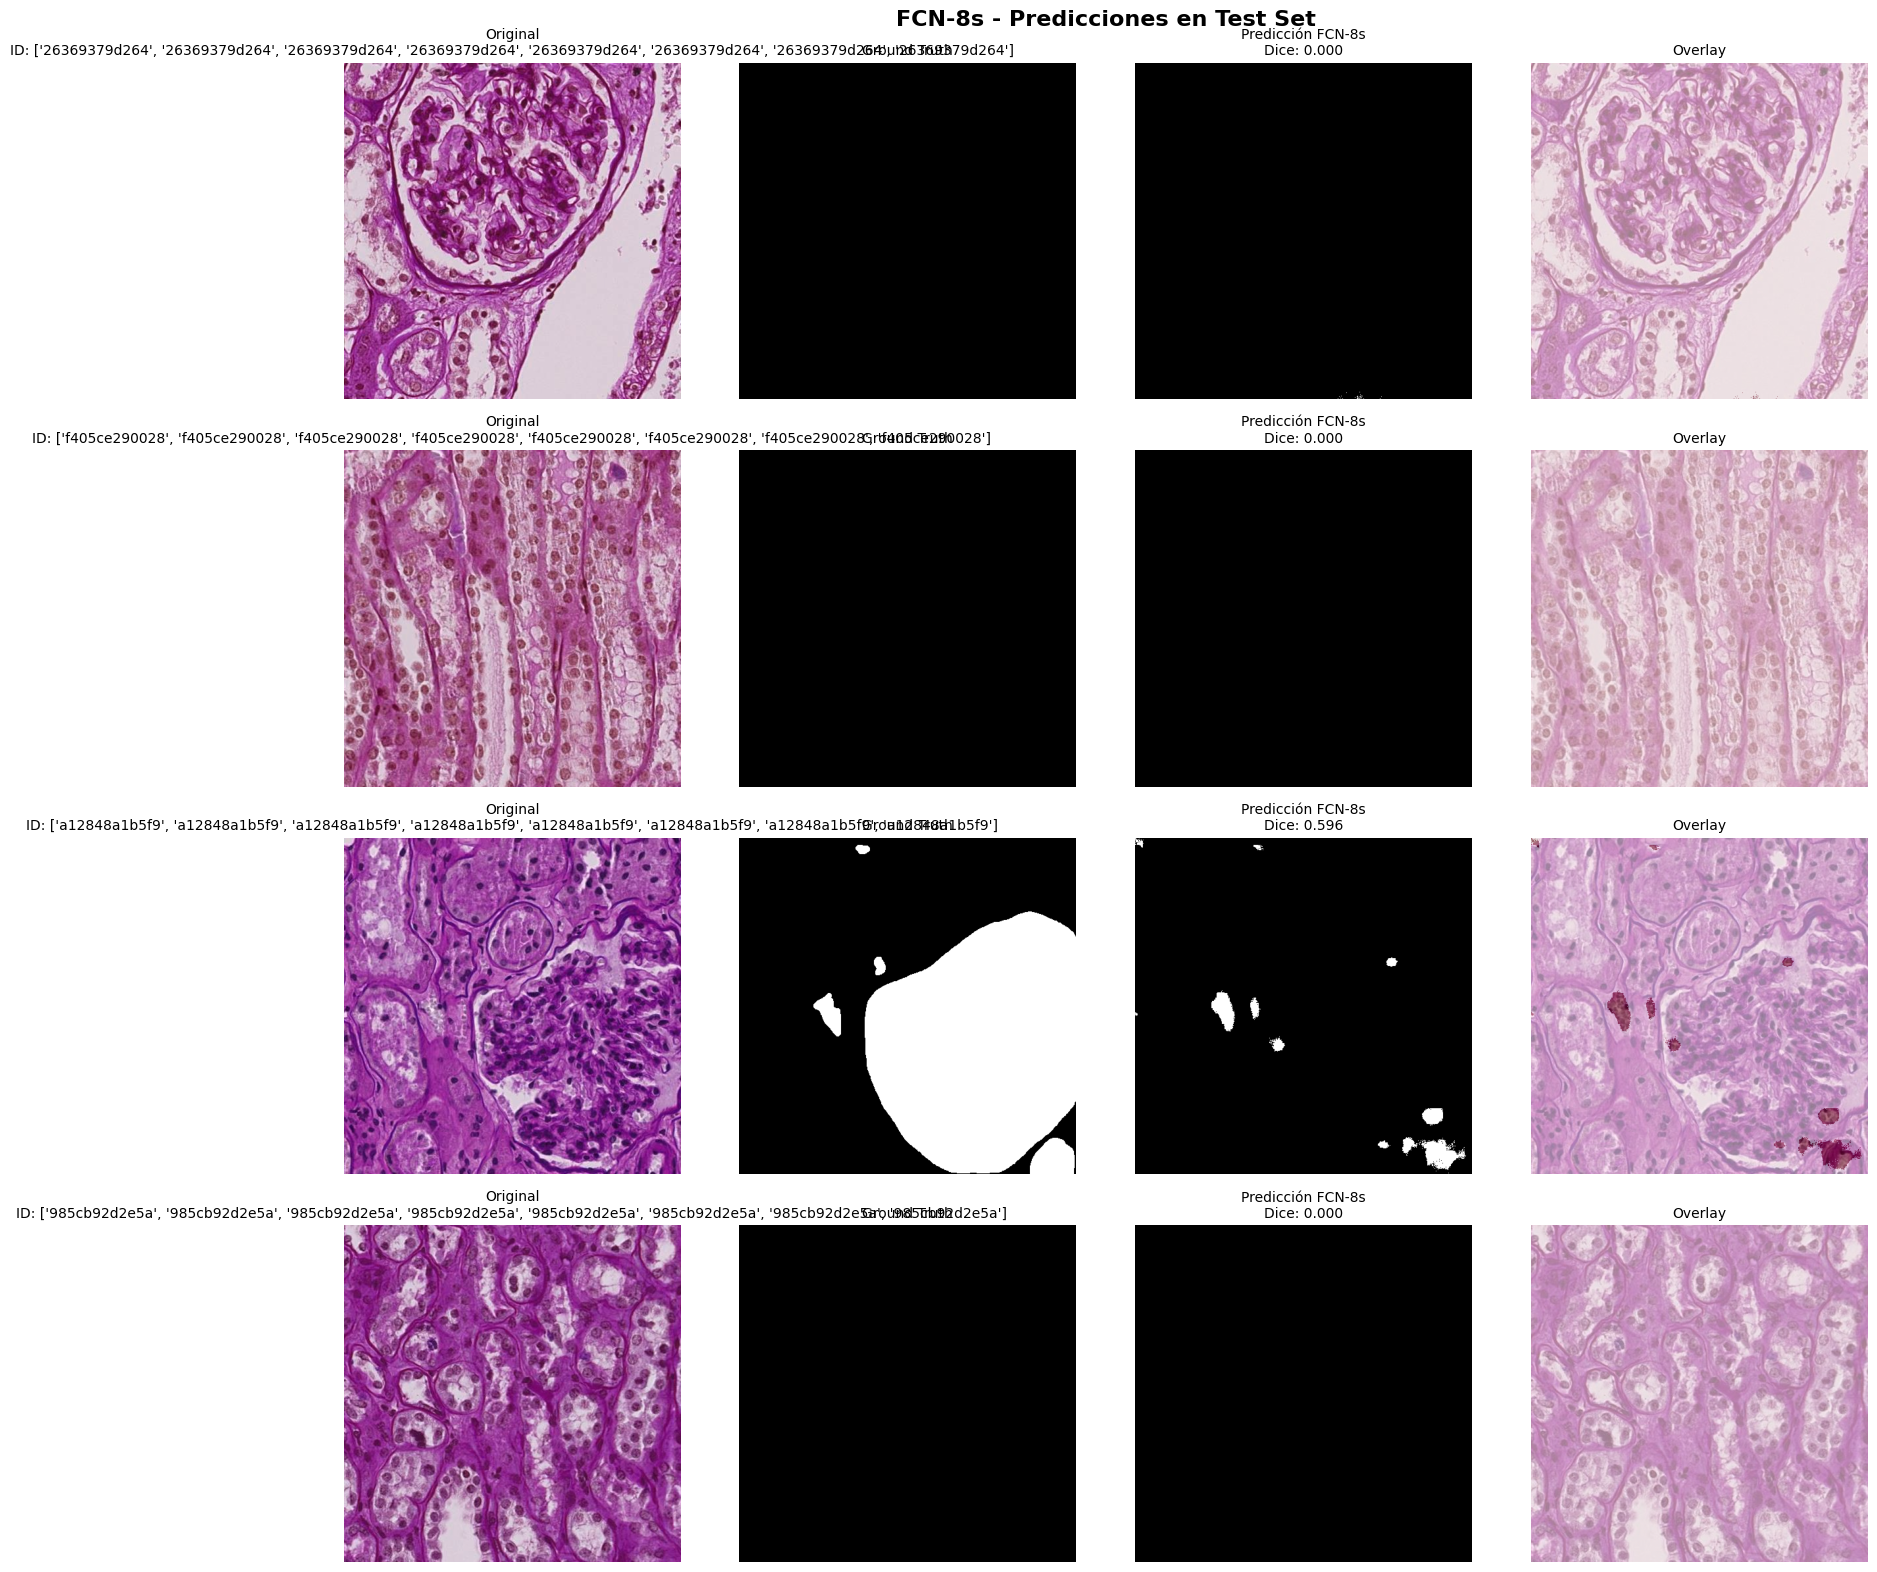

In [28]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

model.eval()
with torch.no_grad():
    # Obtener 4 ejemplos del test set
    images, masks, tile_ids = next(iter(test_loader))
    images_gpu = images.to(device)

    outputs = model(images_gpu)
    predictions = torch.argmax(outputs, dim=1).cpu()

    for i in range(4):
        # Desnormalizar imagen
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        mask_gt = masks[i].cpu().numpy()
        mask_pred = predictions[i].numpy()

        # Calcular métricas individuales
        valid_mask = (mask_gt != 255)
        if valid_mask.sum() > 0:
            dice_individual = (2. * np.sum(mask_pred[valid_mask] * mask_gt[valid_mask])) / \
                             (np.sum(mask_pred[valid_mask]) + np.sum(mask_gt[valid_mask]) + 1e-7)
        else:
            dice_individual = 0.0

        # Imagen original
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Original\nID: {tile_ids[i]}', fontsize=10)
        axes[i, 0].axis('off')

        # Ground truth
        axes[i, 1].imshow(mask_gt, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground Truth', fontsize=10)
        axes[i, 1].axis('off')

        # Predicción
        axes[i, 2].imshow(mask_pred, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title(f'Predicción FCN-8s\nDice: {dice_individual:.3f}', fontsize=10)
        axes[i, 2].axis('off')

        # Overlay
        axes[i, 3].imshow(img)
        axes[i, 3].imshow(mask_pred, alpha=0.5, cmap='Reds')
        axes[i, 3].set_title('Overlay', fontsize=10)
        axes[i, 3].axis('off')

plt.suptitle('FCN-8s - Predicciones en Test Set', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fcn8s_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## Resumen

In [31]:
print("RESUMEN FINAL - FCN-8s")

summary_table = f"""
ARQUITECTURA:
  Modelo: FCN-8s (Fully Convolutional Network)
  Backbone: VGG16 preentrenado (ImageNet)
  Parámetros: {total_params:,} ({total_params/1e6:.1f}M)

ENTRENAMIENTO:
  Épocas entrenadas: {len(history['train_loss'])}
  Tiempo total: {sum(history['epoch_times'])/60:.1f} minutos
  Mejor época: {checkpoint['epoch'] + 1}

RESULTADOS EN VALIDACIÓN:
  Dice Score:  {best_dice:.4f}
  IoU:         {history['val_iou'][checkpoint['epoch']]:.4f}
  Precision:   {history['val_precision'][checkpoint['epoch']]:.4f}
  Recall:      {history['val_recall'][checkpoint['epoch']]:.4f}
  F1-Score:    {history['val_f1'][checkpoint['epoch']]:.4f}

RESULTADOS EN TEST:
  Dice Score:  {np.mean(test_metrics['dice']):.4f} ± {np.std(test_metrics['dice']):.4f}
  IoU:         {np.mean(test_metrics['iou']):.4f} ± {np.std(test_metrics['iou']):.4f}
  Precision:   {np.mean(test_metrics['precision']):.4f} ± {np.std(test_metrics['precision']):.4f}
  Recall:      {np.mean(test_metrics['recall']):.4f} ± {np.std(test_metrics['recall']):.4f}
  F1-Score:    {np.mean(test_metrics['f1']):.4f} ± {np.std(test_metrics['f1']):.4f}
"""

print(summary_table)

RESUMEN FINAL - FCN-8s

ARQUITECTURA:
  Modelo: FCN-8s (Fully Convolutional Network)
  Backbone: VGG16 preentrenado (ImageNet)
  Parámetros: 134,271,430 (134.3M)

ENTRENAMIENTO:
  Épocas entrenadas: 23
  Tiempo total: 327.2 minutos
  Mejor época: 18

RESULTADOS EN VALIDACIÓN:
  Dice Score:  0.5063
  IoU:         0.3764
  Precision:   0.5878
  Recall:      0.4753
  F1-Score:    0.5063

RESULTADOS EN TEST:
  Dice Score:  0.4994 ± 0.2675
  IoU:         0.3710 ± 0.2166
  Precision:   0.5609 ± 0.2946
  Recall:      0.4798 ± 0.2716
  F1-Score:    0.4994 ± 0.2675

